In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
# jax.config.update("jax_default_device", jax.devices("gpu")[0])

In [30]:
datadir = Path("../../data/datasets/burgers_1d/data")
dataset_xr = xr.open_dataset(
    datadir / "valid" / "burgers_1d_validation_grf_seed=11.hdf5",
    engine="h5netcdf",
    chunks={},
)  # .isel({"t": slice(0, 80)})
dataset_xr

<xarray.Dataset> Size: 808MB
Dimensions:  (ic: 10000, t: 101, dim: 1, x: 100, param: 2)
Coordinates:
  * t        (t) float64 808B 0.0 0.005 0.01 0.015 0.02 ... 0.485 0.49 0.495 0.5
  * dim      (dim) <U3 12B 'u_0'
  * x        (x) float64 800B 0.0 0.01 0.02 0.03 0.04 ... 0.96 0.97 0.98 0.99
  * param    (param) <U1 8B 'a' 'b'
Dimensions without coordinates: ic
Data variables:
    values   (ic, t, dim, x) float64 808MB dask.array<chunksize=(10000, 101, 1, 100), meta=np.ndarray>
    coeffs   (ic, param) float64 160kB dask.array<chunksize=(10000, 2), meta=np.ndarray>

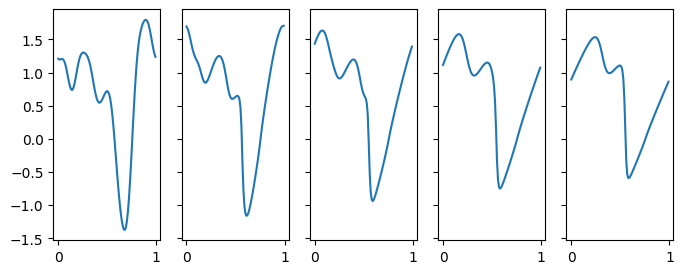

In [33]:
sample_idx = 0
fig, axes = plt.subplots(1, 5, figsize=(8, 3), sharey="row")

for j, ax in enumerate(axes):
    ax.plot(dataset_xr.coords["x"], dataset_xr["values"][sample_idx, 10 * j, 0])


In [34]:
datadir = Path("../../data/datasets/burgers_1d/data/train")
dataset_xr = xr.open_mfdataset(
    sorted(list(datadir.glob("burgers_1d_train_grf_seed=*.hdf5"))),
    combine="nested",
    concat_dim="ic",
    engine="h5netcdf",
)